# Steam Turbine Digital Twin using Machine Learning

## Project Objective

This project develops a machine learning-based digital twin of a steam turbine operating in a thermal power plant.

The objective is to predict key performance indicators using operational plant parameters.

### Target Variables

- Gross Load (MW)
- HP Turbine Efficiency (%)
- NPHR (Kcal/Kwh)
- NTHR (Kcal/Kwh)

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

### Machine Learning Model

- Random Forest Regressor
- Extra Trees Regressor

In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/itsjayasingh/turbine/industrial_dataset.csv


In [20]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/itsjayasingh/turbine/industrial_dataset.csv")

print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(50091, 55)
Index(['Timestamp', 'Main steam flow (t/h)',
       'Main steam temperature (boiler side) (℃)',
       'Main steam pressure (boiler side) (Mpa)',
       'Reheat steam temperature (boiler side) (℃)',
       'Superheater desuperheating water flow (t/h)',
       'Reheater desuperheating water flow (t/h)', 'Feedwater temperature (℃)',
       'Feedwater flow (t/h)', 'Flue gas temperature (℃)',
       'Boiler oxygen level (%)', 'Main steam temperature (turbine side) (℃)',
       'Main steam pressure (turbine side) (MPa)',
       'Reheat steam temperature (turbine side) (℃)',
       'Reheat steam pressure (turbine side) (MPa)',
       'Control stage pressure (Mpa)', 'High exhaust pressure (Mpa)',
       'Feedwater pressure (MPa)', 'Condenser vacuum (kPa)',
       'Circulating water outlet temperature (℃)', 'SO2 (mg/m3)',
       'Nox (mg/m3)', 'CO (mg/m3)', 'CO2 (ppm)', 'O2 (%)', 'Velocity (m/s)',
       'Temp. (°C)', 'Pressure (Kpa)', 'Flow rate (KNm3/h)', 'Opacity (%)',
       'D

In [21]:
# Missing values in each column

df.isnull().sum()

Timestamp                                      0
Main steam flow (t/h)                          0
Main steam temperature (boiler side) (℃)       0
Main steam pressure (boiler side) (Mpa)        0
Reheat steam temperature (boiler side) (℃)     0
Superheater desuperheating water flow (t/h)    0
Reheater desuperheating water flow (t/h)       0
Feedwater temperature (℃)                      0
Feedwater flow (t/h)                           0
Flue gas temperature (℃)                       0
Boiler oxygen level (%)                        0
Main steam temperature (turbine side) (℃)      0
Main steam pressure (turbine side) (MPa)       0
Reheat steam temperature (turbine side) (℃)    0
Reheat steam pressure (turbine side) (MPa)     0
Control stage pressure (Mpa)                   0
High exhaust pressure (Mpa)                    0
Feedwater pressure (MPa)                       0
Condenser vacuum (kPa)                         0
Circulating water outlet temperature (℃)       0
SO2 (mg/m3)         

In [22]:
df.describe()

,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,APH Leakage (%),Corrected Flue Gas Out Temperature (°C),APH Effectiveness (%),Coal Flow (t/h),Energy Input From Boiler (Kcal/h),NTHR (Kcal/Kwh),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg)
count,50091.000000,50091.000000,50091.000000,50091.000000,50091.000000,50091.000000,50091.000000,50091.000000,50091.000000,50091.000000,...,50091.000000,50091.000000,50091.000000,50091.000000,5.009100e+04,50091.000000,50091.000000,50091.000000,50091.000000,50091.000000
mean,830.140953,567.202985,14.271761,565.599647,81.624853,2.743052,235.287399,833.823153,122.962674,4.732849,...,2.175504,124.932680,71.317392,167.234487,7.112048e+08,2539.762412,2711.069937,296.349555,280.048641,4253.553085
std,4.683706,0.555854,0.117836,0.477248,5.852727,1.010369,4.502891,7.511976,1.162752,0.124840,...,0.901527,1.237339,0.370395,1.542815,6.238664e+06,21.874199,23.164779,1.264762,1.190617,9.215021
min,809.135110,564.842746,13.776701,563.718841,56.746209,-1.067079,216.472714,798.273073,118.205588,4.203964,...,-2.012666,119.961357,69.690869,160.167924,6.835101e+08,2448.618858,2617.292578,291.158122,275.263586,4209.862865
25%,826.973103,566.828981,14.191619,565.276976,77.727881,2.054898,232.204843,828.795728,122.179461,4.648017,...,1.567698,124.107297,71.066621,166.187097,7.070000e+08,2524.931798,2695.547391,295.497000,279.245031,4247.345909
50%,830.131781,567.204240,14.271981,565.600689,81.609372,2.743124,235.251036,833.823241,122.960952,4.732443,...,2.174398,124.933402,71.317749,167.238075,7.111549e+08,2539.874284,2711.121727,296.346448,280.055509,4253.612466
75%,833.282707,567.575838,14.350994,565.921870,85.579139,3.426424,238.303738,838.894816,123.746160,4.817235,...,2.786348,125.772467,71.569521,168.274371,7.154177e+08,2554.583667,2726.598046,297.201733,280.856959,4259.829701
max,849.581599,569.552365,14.717443,567.389062,107.869563,6.821261,254.675460,871.567190,128.002414,5.226114,...,6.287161,130.209755,72.798067,173.491176,7.368185e+08,2632.123404,2811.423051,301.417686,284.569521,4292.227380


In [23]:
print(df.shape)

(50091, 55)


In [24]:
df.isnull().sum().sum()

np.int64(0)

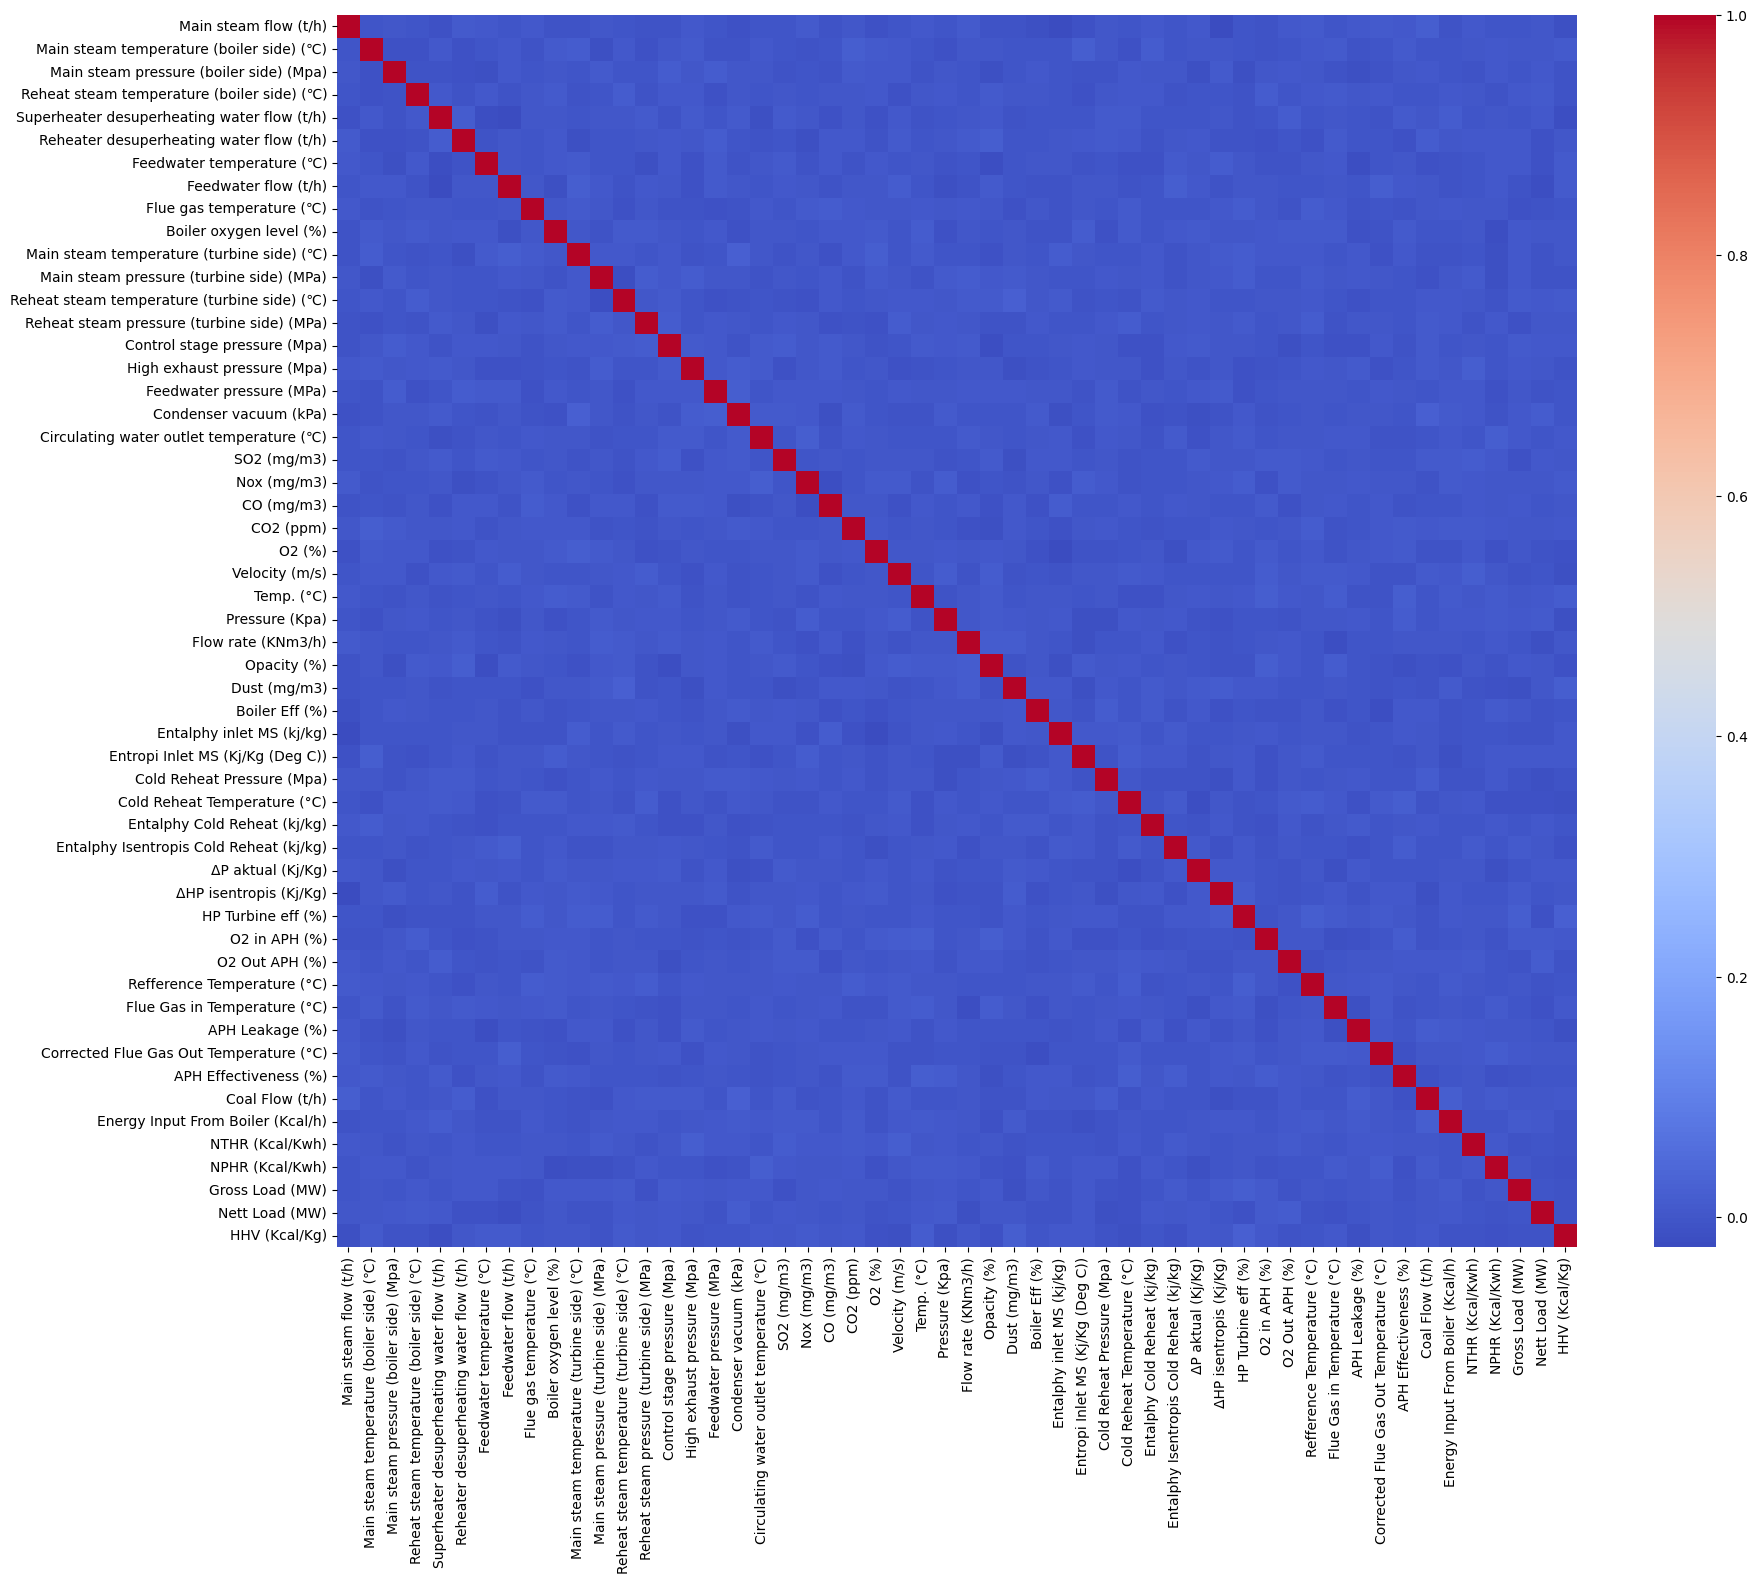

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/itsjayasingh/turbine/industrial_dataset.csv")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20,16))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [26]:
print(df.columns.tolist())

['Timestamp', 'Main steam flow (t/h)', 'Main steam temperature (boiler side) (℃)', 'Main steam pressure (boiler side) (Mpa)', 'Reheat steam temperature (boiler side) (℃)', 'Superheater desuperheating water flow (t/h)', 'Reheater desuperheating water flow (t/h)', 'Feedwater temperature (℃)', 'Feedwater flow (t/h)', 'Flue gas temperature (℃)', 'Boiler oxygen level (%)', 'Main steam temperature (turbine side) (℃)', 'Main steam pressure (turbine side) (MPa)', 'Reheat steam temperature (turbine side) (℃)', 'Reheat steam pressure (turbine side) (MPa)', 'Control stage pressure (Mpa)', 'High exhaust pressure (Mpa)', 'Feedwater pressure (MPa)', 'Condenser vacuum (kPa)', 'Circulating water outlet temperature (℃)', 'SO2 (mg/m3)', 'Nox (mg/m3)', 'CO (mg/m3)', 'CO2 (ppm)', 'O2 (%)', 'Velocity (m/s)', 'Temp. (°C)', 'Pressure (Kpa)', 'Flow rate (KNm3/h)', 'Opacity (%)', 'Dust (mg/m3)', 'Boiler Eff (%)', 'Entalphy inlet MS (kj/kg)', 'Entropi Inlet MS (Kj/Kg (Deg C))', 'Cold Reheat Pressure (Mpa)', 'Co

## Model 1: Gross Load (MW)

In [27]:
targets = [
    "Timestamp",
    "Gross Load (MW)",
    "HP Turbine eff (%)",
    "NPHR (Kcal/Kwh)",
    "NTHR (Kcal/Kwh)"
]

X = df.drop(columns=targets)
y = df["Gross Load (MW)"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(42577, 50)
(7514, 50)
(42577,)
(7514,)


In [30]:
print(X.shape)
print(y.shape)

(50091, 50)
(50091,)


In [31]:
print(X.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [32]:
print(X.isnull().sum().sum())

0


In [33]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50091 entries, 0 to 50090
Data columns (total 50 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Main steam flow (t/h)                        50091 non-null  float64
 1   Main steam temperature (boiler side) (℃)     50091 non-null  float64
 2   Main steam pressure (boiler side) (Mpa)      50091 non-null  float64
 3   Reheat steam temperature (boiler side) (℃)   50091 non-null  float64
 4   Superheater desuperheating water flow (t/h)  50091 non-null  float64
 5   Reheater desuperheating water flow (t/h)     50091 non-null  float64
 6   Feedwater temperature (℃)                    50091 non-null  float64
 7   Feedwater flow (t/h)                         50091 non-null  float64
 8   Flue gas temperature (℃)                     50091 non-null  float64
 9   Boiler oxygen level (%)                      50091 non-null  float64
 10

In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=20, n_jobs=-1, random_state=42)

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score =", r2_score(y_test, y_pred))
print("MAE =", mean_absolute_error(y_test, y_pred))

R2 Score = 0.011041824413983492
MAE = 0.992070827965655


In [37]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(20))

           Actual   Predicted
39045  296.521982  296.694262
21176  299.012899  296.447079
12488  295.979375  296.753731
16293  295.141782  296.908149
31142  295.041166  296.610154
41677  296.272166  296.501558
41967  295.949283  296.388772
8853   296.599235  296.177466
18826  297.500054  296.291966
9205   296.462080  296.252690
44167  296.472715  296.614869
38299  294.534811  296.187618
6433   298.645411  296.794932
24268  297.189813  296.414197
1812   292.878204  296.893626
3184   295.974986  296.079001
12691  293.815931  296.433427
725    293.986639  296.107590
26628  293.566354  296.350365
32492  293.110373  296.784515


In [38]:
print(y.name)

print(y.head())

print(y.describe())

print(y.nunique())

Gross Load (MW)
0    295.240527
1    295.522844
2    295.093870
3    295.123758
4    295.661029
Name: Gross Load (MW), dtype: float64
count    50091.000000
mean       296.349555
std          1.264762
min        291.158122
25%        295.497000
50%        296.346448
75%        297.201733
max        301.417686
Name: Gross Load (MW), dtype: float64
50091


In [39]:
print(X.shape)
print(y.shape)

(50091, 50)
(50091,)


In [40]:
print(y_pred[:10])

[296.69426216 296.44707869 296.7537307  296.90814937 296.61015411
 296.50155827 296.38877191 296.17746642 296.29196634 296.25268983]


In [41]:
print(y_test.iloc[:10].values)

[296.52198243 299.01289944 295.97937479 295.141782   295.04116558
 296.27216606 295.9492826  296.59923468 297.50005437 296.46207994]


In [42]:
print(y.std())

1.2647621755158405


In [43]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)
print("Target Std =", y.std())
print("MAE / Std =", mae / y.std())

MAE = 0.992070827965655
Target Std = 1.2647621755158405
MAE / Std = 0.7843931825056623


## Model 2: High Pressure Turbine Efficiency(%)

In [44]:
targets = [
    "Timestamp",
    "Gross Load (MW)",
    "HP Turbine eff (%)",
    "NPHR (Kcal/Kwh)",
    "NTHR (Kcal/Kwh)"
]

X = df.drop(columns=targets)
Y = df["HP Turbine eff (%)"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.15,
    random_state = 42
)

In [46]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators = 20,
    random_state = 42,
    n_jobs = -1
)
model.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=20, n_jobs=-1, random_state=42)

In [47]:
Y_predict = model.predict(X_test)

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R^2 score = ", r2_score(Y_test, Y_predict))
print("MAE = ", mean_absolute_error(Y_test, Y_predict))

R^2 score =  0.00836704995185411
MAE =  0.2753247070348218


In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                                        Feature  Importance
6                     Feedwater temperature (℃)    0.022052
44      Corrected Flue Gas Out Temperature (°C)    0.021120
1      Main steam temperature (boiler side) (℃)    0.021078
37                            ΔP aktual (Kj/Kg)    0.021069
0                         Main steam flow (t/h)    0.020997
5      Reheater desuperheating water flow (t/h)    0.020867
36      Entalphy Isentropis Cold Reheat (kj/kg)    0.020768
20                                  Nox (mg/m3)    0.020616
12  Reheat steam temperature (turbine side) (℃)    0.020597
19                                  SO2 (mg/m3)    0.020576


In [50]:
print(df["HP Turbine eff (%)"].describe())

count    50091.000000
mean        80.776370
std          0.341627
min         79.333797
25%         80.546637
50%         80.777449
75%         81.009623
max         82.242315
Name: HP Turbine eff (%), dtype: float64


In [51]:
targets = [
    "NPHR (Kcal/Kwh)",
    "NTHR (Kcal/Kwh)",
    "Boiler Eff (%)"
]

for col in targets:
    print("\n", col)
    print(df[col].describe())


 NPHR (Kcal/Kwh)
count    50091.000000
mean      2711.069937
std         23.164779
min       2617.292578
25%       2695.547391
50%       2711.121727
75%       2726.598046
max       2811.423051
Name: NPHR (Kcal/Kwh), dtype: float64

 NTHR (Kcal/Kwh)
count    50091.000000
mean      2539.762412
std         21.874199
min       2448.618858
25%       2524.931798
50%       2539.874284
75%       2554.583667
max       2632.123404
Name: NTHR (Kcal/Kwh), dtype: float64

 Boiler Eff (%)
count    50091.000000
mean        93.674048
std          0.050987
min         93.448237
25%         93.639685
50%         93.674152
75%         93.708899
max         93.879592
Name: Boiler Eff (%), dtype: float64


## Model 3: Net Plant Heat Rate (Kcal/Kwh)

In [52]:
targets = [
    "Timestamp",
    "Gross Load (MW)",
    "HP Turbine eff (%)",
    "NPHR (Kcal/Kwh)",
    "NTHR (Kcal/Kwh)"
]

X = df.drop(columns=targets)
y = df["NPHR (Kcal/Kwh)"]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

In [54]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=20, n_jobs=-1, random_state=42)

In [55]:
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R² =", r2_score(y_test, y_pred))
print("MAE =", mean_absolute_error(y_test, y_pred))

R² = 0.0010164524441633738
MAE = 18.289880840587134


## Model 4: Net Turbine Heat Rate

In [62]:
targets = [
    "Timestamp",
    "Gross Load (MW)",
    "HP Turbine eff (%)",
    "NPHR (Kcal/Kwh)",
    "NTHR (Kcal/Kwh)"
]

x = df.drop(columns=targets)
y = df["NTHR (Kcal/Kwh)"]

In [63]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( 
    x,
    y,
    test_size = 0.15,
    random_state = 42 )

In [64]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(
    n_estimators = 200,
    random_state = 42,
    n_jobs = -1
)
model.fit(x_train, y_train)

ExtraTreesRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [65]:
y_pred = model.predict(x_test)

In [66]:
from sklearn.metrics import r2_score, mean_absolute_error
print("R2 score = ", r2_score(y_test, y_pred))
print("MAE = ", mean_absolute_error(y_test, y_pred))


R2 score =  0.07696508186543816
MAE =  16.794334103637425


In [67]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    ).head(15)
)

                                      Feature  Importance
23                                     O2 (%)    0.019737
10  Main steam temperature (turbine side) (℃)    0.019659
33                 Cold Reheat Pressure (Mpa)    0.019644
36    Entalphy Isentropis Cold Reheat (kj/kg)    0.019540
47                            Coal Flow (t/h)    0.019517
19                                SO2 (mg/m3)    0.019473
18   Circulating water outlet temperature (℃)    0.019457
49                            NTHR (Kcal/Kwh)    0.019451
39                         HP Turbine eff (%)    0.019357
15                High exhaust pressure (Mpa)    0.019350
25                                 Temp. (°C)    0.019239
41                             O2 Out APH (%)    0.019188
17                     Condenser vacuum (kPa)    0.019150
50                            Gross Load (MW)    0.019092
43               Flue Gas in Temperature (°C)    0.019085


## Results and Comparison

In [73]:
gross_r2 = 0.011041824
gross_mae = 0.99207082

hp_r2 = 0.00836704
hp_mae = 0.275324707

nphr_r2 = 0.001016452
nphr_mae = 18.28988084

nthr_r2 = 0.076965081
nthr_mae = 16.794334103

In [74]:
import pandas as pd

summary_df = pd.DataFrame({
    "Target": [
        "Gross Load",
        "HP Efficiency",
        "NPHR",
        "NTHR"
    ],
    "R2 Score": [
        gross_r2,
        hp_r2,
        nphr_r2,
        nthr_r2
    ],
    "MAE": [
        gross_mae,
        hp_mae,
        nphr_mae,
        nthr_mae
    ]
})

print(summary_df)

          Target  R2 Score        MAE
0     Gross Load  0.011042   0.992071
1  HP Efficiency  0.008367   0.275325
2           NPHR  0.001016  18.289881
3           NTHR  0.076965  16.794334


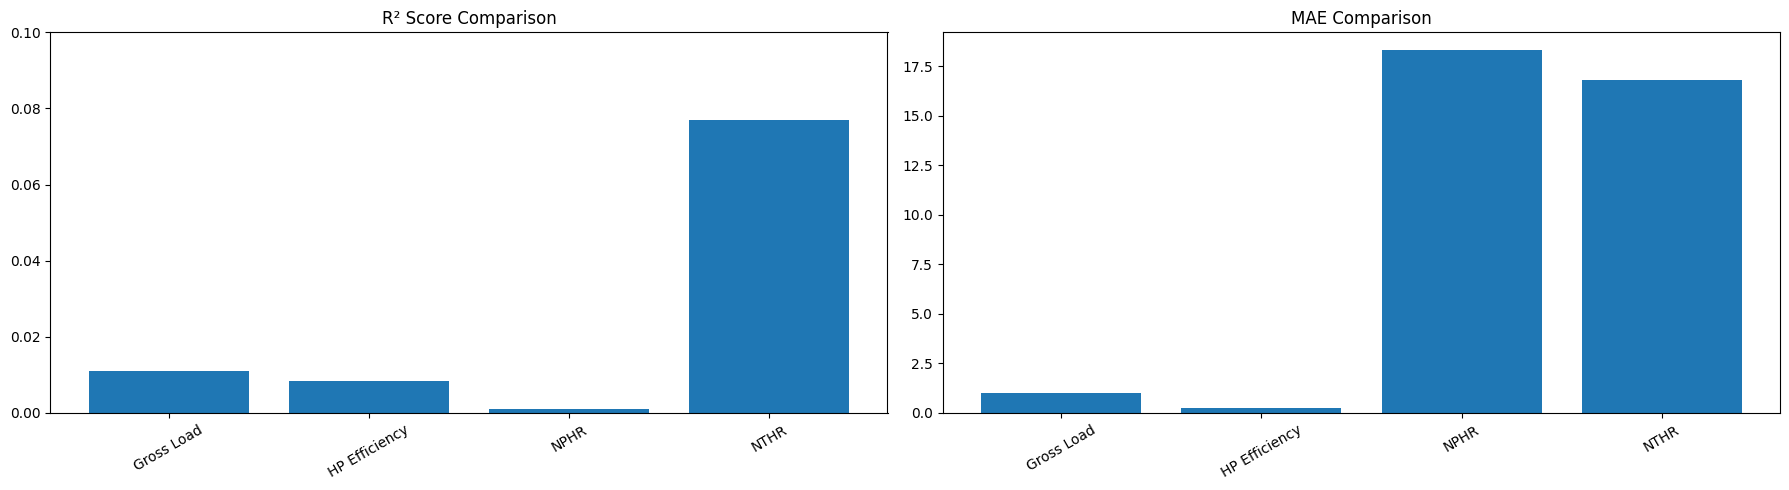

In [78]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# R2
axes[0].bar(summary_df["Target"], summary_df["R2 Score"])
axes[0].set_title("R² Score Comparison")
axes[0].set_ylim(0, 0.1)
axes[0].tick_params(axis='x', rotation=30)

# MAE
axes[1].bar(summary_df["Target"], summary_df["MAE"])
axes[1].set_title("MAE Comparison")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Future Scope

- Real-time plant monitoring
- Predictive maintenance
- Anomaly detection
- Web dashboard deployment
- Integration with live SCADA data